<a href="https://colab.research.google.com/github/EJBass2003/CIS-3902-AI-ML-Eric-Bass/blob/main/random_forest_crime_assignment_EB(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eric Bass
3/29/2026

CIS-3902

# Random Forest Crime Prediction Assignment

## Overview
In this assignment, you will use a **recent real-world crime dataset** to build a **Random Forest classification model**. You will explore the data, prepare it for modeling, train a classifier, evaluate the results, and interpret feature importance.

## Learning Goals
By the end of this assignment, you should be able to:

- explain the difference between **features** and a **target variable**
- prepare data for machine learning
- build a **Random Forest** classifier in Python
- evaluate a classification model using accuracy, a confusion matrix, and a classification report
- interpret **feature importance**
- connect model results to real-world patterns and possible limitations

## Important Note
In this notebook, you are **not predicting whether a crime will happen**.  
You are predicting:

> **Was an arrest made?** (`True` or `False`)

That means your model is learning patterns related to **arrest outcomes**, not crime occurrence itself.


## Step 1: Load the Data

We will use a recent subset of the Chicago crime dataset. The dataset is large, so we will pull a manageable sample for class use.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=50000"
df = pd.read_csv(url)

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14142106,JK187663,2026-03-19T00:00:00.000,007XX E 47TH ST,0560,ASSAULT,SIMPLE,STREET,False,False,...,4,38.0,08A,1182174.0,1874015.0,2026,2026-03-26T15:43:32.000,41.809519,-87.607334,"\n, \n(41.809518699, -87.607333603)"
1,14141351,JK186867,2026-03-19T00:00:00.000,007XX S MICHIGAN AVE,0810,THEFT,OVER $500,HOTEL / MOTEL,False,False,...,4,32.0,06,1177389.0,1897003.0,2026,2026-03-26T15:43:32.000,41.872709,-87.624188,"\n, \n(41.872709056, -87.624187857)"
2,14141288,JK186820,2026-03-19T00:00:00.000,036XX S RHODES AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,4,35.0,06,1180179.0,1881011.0,2026,2026-03-26T15:43:32.000,41.828762,-87.614436,"\n, \n(41.828762287, -87.614436164)"
3,14142257,JK186513,2026-03-19T00:00:00.000,013XX S ALBANY AVE,0810,THEFT,OVER $500,APARTMENT,False,True,...,24,29.0,06,1155926.0,1893559.0,2026,2026-03-26T15:43:32.000,41.863718,-87.703081,"\n, \n(41.863717908, -87.703081168)"
4,14140758,JK186030,2026-03-19T00:00:00.000,006XX N CENTRAL AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,ALLEY,False,True,...,29,25.0,14,1138919.0,1903598.0,2026,2026-03-26T15:43:32.000,41.891592,-87.765270,"\n, \n(41.891591889, -87.765269754)"


## Step 2: Explore the Data

Look at the structure of the dataset.

### Questions
1. What does each row represent?
2. Which variables look potentially useful for prediction?
3. Which variable appears to be the target for this assignment?


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    50000 non-null  int64  
 1   case_number           50000 non-null  object 
 2   date                  50000 non-null  object 
 3   block                 50000 non-null  object 
 4   iucr                  50000 non-null  object 
 5   primary_type          50000 non-null  object 
 6   description           50000 non-null  object 
 7   location_description  49752 non-null  object 
 8   arrest                50000 non-null  bool   
 9   domestic              50000 non-null  bool   
 10  beat                  50000 non-null  int64  
 11  district              50000 non-null  int64  
 12  ward                  50000 non-null  int64  
 13  community_area        49998 non-null  float64
 14  fbi_code              50000 non-null  object 
 15  x_coordinate       

In [ ]:
df.describe(include='all')

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
count,5.000000e+04,50000,50000,50000,50000,50000,50000,49752,50000,50000,...,50000.000000,49998.000000,50000,4.993600e+04,4.993600e+04,50000.000000,50000,49936.000000,49936.000000,49936
unique,NaN,49997,27280,16933,284,28,266,107,2,2,...,NaN,NaN,24,NaN,NaN,NaN,73,NaN,NaN,33673
top,NaN,JK173315,2026-01-01T00:00:00.000,0000X N STATE ST,0486,THEFT,SIMPLE,STREET,False,False,...,NaN,NaN,06,NaN,NaN,NaN,2026-03-14T15:41:39.000,NaN,NaN,"\n, \n(41.754592961, -87.741528537)"
freq,NaN,2,49,136,4185,11018,6139,13412,42141,40213,...,NaN,NaN,12267,NaN,NaN,NaN,41863,NaN,NaN,76
mean,1.407602e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.811240,36.321573,NaN,1.165780e+06,1.887061e+06,2025.862000,NaN,41.845667,-87.667132,NaN
std,6.035679e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.938009,21.384077,NaN,1.618543e+04,3.120568e+04,0.344903,NaN,0.085814,0.058934,NaN
min,2.898300e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,NaN,1.094587e+06,1.814333e+06,2025.000000,NaN,41.645288,-87.927365,NaN
25%,1.408134e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.000000,22.000000,NaN,1.154593e+06,1.860322e+06,2026.000000,NaN,41.772201,-87.707778,NaN
50%,1.410238e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.000000,32.000000,NaN,1.167626e+06,1.893058e+06,2026.000000,NaN,41.862218,-87.660138,NaN
75%,1.412218e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,34.000000,53.000000,NaN,1.176963e+06,1.909912e+06,2026.000000,NaN,41.908431,-87.626156,NaN


## Step 3: Data Cleaning

We will keep a smaller set of variables for this assignment.

- `primary_type`: type of crime
- `arrest`: whether an arrest was made
- `domestic`: whether the incident was domestic-related
- `district`: police district
- `latitude`, `longitude`: location

Then we will remove rows with missing values.


In [ ]:
df = df[['primary_type', 'arrest', 'domestic', 'district', 'latitude', 'longitude']]
df = df.dropna()

df.head()

,primary_type,arrest,domestic,district,latitude,longitude
0,ASSAULT,False,False,2,41.809519,-87.607334
1,THEFT,False,False,1,41.872709,-87.624188
2,THEFT,False,False,2,41.828762,-87.614436
3,THEFT,False,True,10,41.863718,-87.703081
4,CRIMINAL DAMAGE,False,True,15,41.891592,-87.765270


### Short Response
Why might missing values cause problems in machine learning and mapping?


## Step 4: Interactive Crime Map

Now that the data has been cleaned, we can build a map using latitude and longitude.

We are placing this **after data cleaning** because missing values in location fields can cause mapping tools to fail.

### Note
We will use `CartoDB positron` for the base map. This tile option often works better in notebook environments than the default map tiles.


In [ ]:
import folium

m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)

sample_df = df.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    color = "red" if row['arrest'] else "blue"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m

### Interpretation Questions
1. Do crime points appear evenly spread out, or do they cluster in certain areas?
2. Do you see any visible differences between arrest and non-arrest locations?
3. If location turns out to be important later, does this map help explain why?


## Step 5: Arrest Rate by Crime Type

This chart helps you see which crime categories are more likely to lead to an arrest.


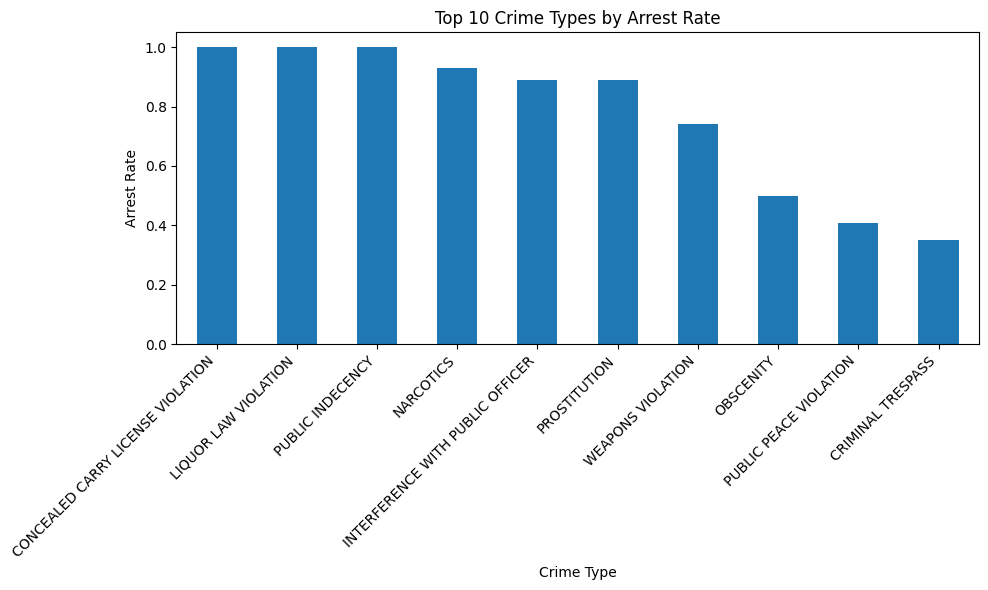

In [ ]:
arrest_rates = df.groupby('primary_type')['arrest'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
arrest_rates.head(10).plot(kind='bar')
plt.title("Top 10 Crime Types by Arrest Rate")
plt.ylabel("Arrest Rate")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation Question
Which crime types seem most likely to lead to arrest? Does this surprise you?


## Step 6: Feature Engineering

Machine learning models need numeric input. Since `primary_type` and `district` are categorical, we will convert them into dummy variables.


In [ ]:
df = pd.get_dummies(df, columns=['primary_type', 'district'], drop_first=True)
df.head()

,arrest,domestic,latitude,longitude,primary_type_ASSAULT,primary_type_BATTERY,primary_type_BURGLARY,primary_type_CONCEALED CARRY LICENSE VIOLATION,primary_type_CRIMINAL DAMAGE,primary_type_CRIMINAL SEXUAL ASSAULT,...,district_14,district_15,district_16,district_17,district_18,district_19,district_20,district_22,district_24,district_25
0,False,False,41.809519,-87.607334,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,41.872709,-87.624188,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,41.828762,-87.614436,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,41.863718,-87.703081,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,41.891592,-87.765270,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


## Step 7: Define Features and Target

Here is the key setup:

- `X` = the input features used to make predictions
- `y` = the target variable we want to predict

In this assignment:

> `y = arrest`

So the model predicts whether an arrest was made.


In [ ]:
X = df.drop('arrest', axis=1)
y = df['arrest']

## Step 8: Train/Test Split

We split the data so the model trains on one portion and is evaluated on unseen data.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9: Train the Random Forest Model


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 10: Evaluate the Model

We will use:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report**


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8689427312775331

Confusion Matrix:
[[7956  439]
 [ 870  723]]

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.95      0.92      8395
        True       0.62      0.45      0.52      1593

    accuracy                           0.87      9988
   macro avg       0.76      0.70      0.72      9988
weighted avg       0.86      0.87      0.86      9988



## Step 11: Feature Importance

Feature importance tells us which variables had the biggest influence on the model’s predictions.

A larger value means the model used that variable more heavily when making decisions.


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
top_features

,0
latitude,0.325195
longitude,0.319029
primary_type_NARCOTICS,0.146004
primary_type_WEAPONS VIOLATION,0.058006
primary_type_INTERFERENCE WITH PUBLIC OFFICER,0.020583
domestic,0.011231
primary_type_CRIMINAL DAMAGE,0.010260
primary_type_CRIMINAL TRESPASS,0.009706
primary_type_MOTOR VEHICLE THEFT,0.008785
primary_type_BATTERY,0.007632


## Step 12: Visualize Feature Importance

This plot gives a clearer picture of what the model relied on most.


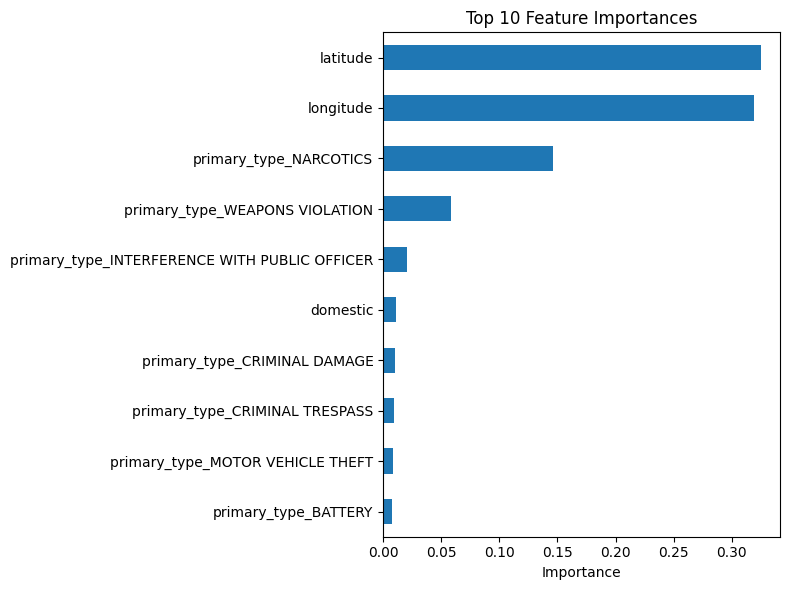

In [ ]:
plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation Questions
1. Which features matter the most? **The features that matter the most are latitude (0.325) and longitude (0.319). Combined, they are vastly more important than any other single variable.**
2. Does the model seem to rely more on **location** or **crime type**? **The model heavily relies on location. Latitude and longitude together make up over 64% of the model's decision-making weight.**
3. What does that suggest about arrest outcomes in the dataset? **This suggests that where an incident happens is a stronger predictor of whether someone will be arrested than the actual type of crime committed.**


## Step 13: Cross Validation

Cross validation helps us check whether the model performs consistently across different subsets of the data.


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

Cross-validation scores: [0.86974369 0.86862922 0.87273455 0.87303495 0.86232102]
Average cross-validation score: 0.8692926856174541


## Step 14: Reflection

Write a short reflection that answers the following:

1. What does the model do well? **Based on the classification report in Step 10, the model is very good at predicting when an arrest will not be made.**
2. What are its limitations? **The model struggles significantly to predict when an arrest will occur. Its recall for the True class is only 0.45, meaning it misses more than half of the actual arrests.**
3. What does feature importance suggest about the strongest predictors of arrest? **It reinforces that geography is the strongest predictor of an arrest. It implies that police presence, neighborhood dynamics, or geographic resource allocation heavily dictate whether a reported incident results in someone being taken into custody.**
4. Why is it important to remember that this model predicts **arrest outcomes** rather than crime itself? **Crime data is often confused with policing data. A model predicting "arrests" is essentially predicting police behavior and systemic outcomes, not the objective occurrence of a crime. For example, high arrest rates for narcotics in a specific neighborhood don't necessarily mean drug use is exclusively high there; it often means police are actively patrolling and enforcing drug laws in that specific neighborhood.**
5. Should a model like this be used in real-world policing decisions? Why or why not? **No, a model like this should not be used to allocate police resources or make real-world policing decisions. Because the model relies so heavily on location, using it for predictive policing would create a dangerous "runaway feedback loop."**
